# Day 4: Fund Performance Analytics

## Objective

This notebook evaluates the performance and risk characteristics of 40 mutual fund schemes using NAV history and benchmark index data.

### Key Metrics

- Daily Returns
- CAGR (1-Year, 3-Year, 5-Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Tracking Error
- Fund Scorecard
- Benchmark Comparison

# 1. Import Libraries and Load Data

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

# Display Settings

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load Data

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

bench = pd.read_csv(
    "../data/raw/Copy of 10_benchmark_indices.csv"
)

# Date Conversion

nav["date"] = pd.to_datetime(nav["date"])

bench["date"] = pd.to_datetime(
    bench["date"]
)

# Dataset Validation

print("NAV Shape:", nav.shape)
print("Performance Shape:", perf.shape)
print("Benchmark Shape:", bench.shape)

print("\nNAV Date Range:")
print(nav["date"].min())
print(nav["date"].max())

print("\nFunds Available:")
print(nav["amfi_code"].nunique())

NAV Shape: (46000, 3)
Performance Shape: (40, 20)
Benchmark Shape: (8050, 3)

NAV Date Range:
2022-01-03 00:00:00
2026-05-29 00:00:00

Funds Available:
40


In [3]:
print(perf.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'expense_flag']


# 2. Daily Return Analysis

## Objective

Compute daily returns for all mutual fund schemes using:

Daily Return = (NAV_t / NAV_t-1) - 1

Validate the distribution of returns using descriptive statistics and visualizations.

In [4]:
# Sort NAV data

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# Daily Return Calculation

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(
    nav[
        [
            "amfi_code",
            "date",
            "nav",
            "daily_return"
        ]
    ].head(10)
)

print("\nMissing Daily Returns:")
print(nav["daily_return"].isna().sum())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073

Missing Daily Returns:
40


### Observation

The first observation for each fund has no previous NAV value available, resulting in one missing daily return per fund.

Expected Missing Values = 40

In [5]:
print(
    nav["daily_return"]
    .describe()
)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


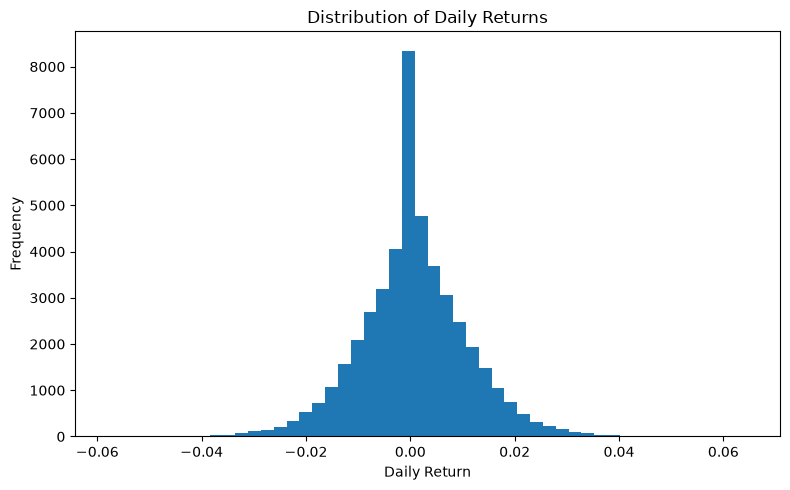

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title(
    "Distribution of Daily Returns"
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/Daily_Return_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Validation

The distribution is expected to be centered near zero with a roughly bell-shaped pattern.

Extreme positive and negative values correspond to periods of significant market volatility.

# 3. CAGR Analysis

## Objective

Measure annualized growth rate over different investment horizons.

### Metrics

- 1-Year CAGR
- 3-Year CAGR
- 5-Year CAGR (subject to data availability)

### Data Availability Check

The NAV history spans from January 2022 to May 2026.

Therefore:

- 1-Year CAGR can be computed.
- 3-Year CAGR can be computed.
- 5-Year CAGR cannot be computed because the available history is less than 5 years.

The analysis will proceed with 1-Year and 3-Year CAGR calculations.

In [7]:
# Latest available date

end_date = nav["date"].max()

start_1yr = end_date - pd.DateOffset(years=1)
start_3yr = end_date - pd.DateOffset(years=3)

nav_1yr = nav[
    nav["date"] >= start_1yr
].copy()

nav_3yr = nav[
    nav["date"] >= start_3yr
].copy()

print("1-Year Start:", start_1yr.date())
print("3-Year Start:", start_3yr.date())
print("End Date:", end_date.date())

1-Year Start: 2025-05-29
3-Year Start: 2023-05-29
End Date: 2026-05-29


In [8]:
cagr_1yr = (
    nav_1yr.groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
    .reset_index()
)

cagr_1yr["cagr_1yr"] = (
    (cagr_1yr["end_nav"] / cagr_1yr["start_nav"])
    ** (1 / 1)
    - 1
)

cagr_1yr.head()

,amfi_code,start_nav,end_nav,cagr_1yr
0,100016,596.8877,583.6113,-0.022243
1,100025,30.7452,31.8843,0.037050
2,100033,223.1951,342.0072,0.532324
3,101206,522.7639,773.2939,0.479241
4,101207,71.0180,53.9836,-0.239860


In [9]:
cagr_3yr = (
    nav_3yr.groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
    .reset_index()
)

cagr_3yr["cagr_3yr"] = (
    (cagr_3yr["end_nav"] / cagr_3yr["start_nav"])
    ** (1 / 3)
    - 1
)

cagr_3yr.head()

,amfi_code,start_nav,end_nav,cagr_3yr
0,100016,561.5519,583.6113,0.012926
1,100025,28.4135,31.8843,0.039164
2,100033,147.2155,342.0072,0.324425
3,101206,360.4971,773.2939,0.289677
4,101207,61.3081,53.9836,-0.041524


In [12]:
cagr_table = (
    cagr_1yr[
        ["amfi_code", "cagr_1yr"]
    ]
    .merge(
        cagr_3yr[
            ["amfi_code", "cagr_3yr"]
        ],
        on="amfi_code"
    )
)

cagr_table = cagr_table.merge(
    perf[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

cagr_table = cagr_table.sort_values(
    "cagr_3yr",
    ascending=False
)

cagr_table[
    [
        "scheme_name",
        "category",
        "cagr_1yr",
        "cagr_3yr"
    ]
].head(10)

,scheme_name,category,cagr_1yr,cagr_3yr
16,Axis Midcap Fund - Regular - Growth,Mid Cap,0.222611,0.351118
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,0.203607,0.340009
24,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,0.130643,0.324874
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,0.532324,0.324425
25,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.296047,0.317775
19,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,0.604373,0.304565
30,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,0.266571,0.295828
36,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,0.397518,0.291789
3,ABSL Frontline Equity Fund - Regular - Growth,Large Cap,0.479241,0.289677
39,DSP Small Cap Fund - Regular - Growth,Small Cap,0.651387,0.270004


### Key Metrics

- CAGR measures annualized growth over the investment period.
- Higher CAGR indicates stronger long-term performance.
- Rankings are based primarily on 3-Year CAGR because it provides a more stable performance measure than a single year.

# 4. Sharpe Ratio Analysis

### Objective

Measure risk-adjusted performance using the Sharpe Ratio.

Formula:

Sharpe Ratio = (Rp − Rf) / σ

Where:

- Rp = Annualized Fund Return
- Rf = Risk-Free Rate (6.5%)
- σ = Annualized Volatility

A higher Sharpe Ratio indicates better returns per unit of risk.

In [13]:
RF = 0.065

sharpe_df = (
    nav_3yr.groupby("amfi_code")
    .agg(
        mean_daily_return=("daily_return","mean"),
        std_daily_return=("daily_return","std")
    )
    .reset_index()
)

sharpe_df["annual_return"] = (
    sharpe_df["mean_daily_return"] * 252
)

sharpe_df["annual_volatility"] = (
    sharpe_df["std_daily_return"] * np.sqrt(252)
)

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["annual_return"] - RF)
    /
    sharpe_df["annual_volatility"]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df = sharpe_df.merge(
    perf[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

sharpe_df[
    [
        "scheme_name",
        "category",
        "sharpe_ratio"
    ]
].head(10)

,scheme_name,category,sharpe_ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.614434
1,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,1.479645
2,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,1.433735
3,ABSL Frontline Equity Fund - Regular - Growth,Large Cap,1.298103
4,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,1.252066
5,Axis Midcap Fund - Regular - Growth,Mid Cap,1.243753
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,1.224870
7,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,1.155939
8,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,1.135917
9,DSP Midcap Fund - Regular - Growth,Mid Cap,1.034755


In [14]:
print(
    sharpe_df["sharpe_ratio"]
    .describe()
)

count    40.000000
mean      0.516184
std       0.717108
min      -1.201122
25%      -0.233920
50%       0.744162
75%       1.017961
max       1.614434
Name: sharpe_ratio, dtype: float64


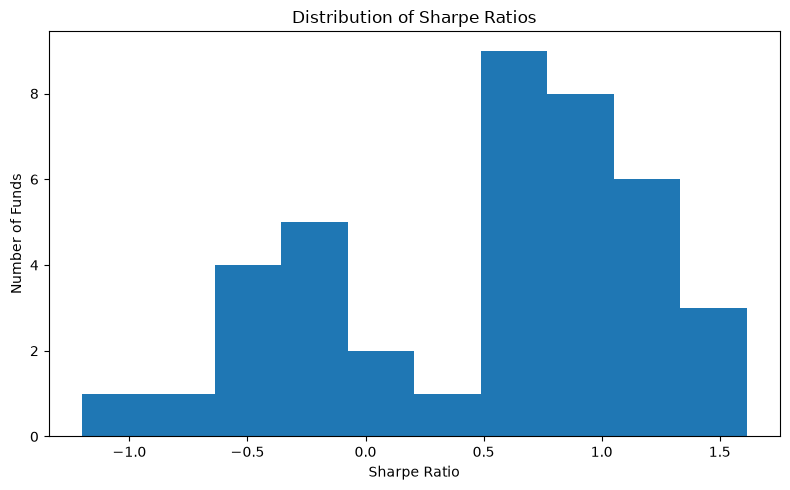

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    sharpe_df["sharpe_ratio"],
    bins=10
)

plt.title("Distribution of Sharpe Ratios")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    "../reports/Sharpe_Ratio_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Validation

- Positive Sharpe Ratios indicate returns exceeding the risk-free rate.
- Higher values represent better risk-adjusted performance.
- Negative values suggest the fund underperformed the risk-free benchmark after accounting for volatility.

# 5. Sortino Ratio Analysis

### Objective

Measure risk-adjusted returns using downside volatility only.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Deviation

Where:

- Rp = Annualized Fund Return
- Rf = Risk-Free Rate (6.5%)
- Downside Deviation = Standard deviation of negative return days only

Unlike the Sharpe Ratio, the Sortino Ratio penalizes only harmful volatility.

In [16]:
RF = 0.065

sortino_results = []

for fund, grp in nav_3yr.groupby("amfi_code"):

    mean_daily_return = grp["daily_return"].mean()

    annual_return = mean_daily_return * 252

    downside_returns = grp.loc[
        grp["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    sortino_ratio = (
        (annual_return - RF)
        /
        (downside_std * np.sqrt(252))
    )

    sortino_results.append([
        fund,
        annual_return,
        downside_std,
        sortino_ratio
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "annual_return",
        "downside_std",
        "sortino_ratio"
    ]
)

sortino_df = sortino_df.merge(
    perf[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df[
    [
        "scheme_name",
        "category",
        "sortino_ratio"
    ]
].head(10)

,scheme_name,category,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,2.637558
24,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,2.607085
19,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,2.535686
3,ABSL Frontline Equity Fund - Regular - Growth,Large Cap,2.386585
30,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,2.283838
16,Axis Midcap Fund - Regular - Growth,Mid Cap,2.227587
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,2.099624
25,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,1.953703
36,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,1.913427
8,UTI Flexi Cap Fund - Regular - Growth,Flexi Cap,1.808566


In [17]:
print(
    sortino_df["sortino_ratio"]
    .describe()
)

count    40.000000
mean      0.895485
std       1.281985
min      -2.556053
25%      -0.386704
50%       1.271167
75%       1.757935
max       2.637558
Name: sortino_ratio, dtype: float64


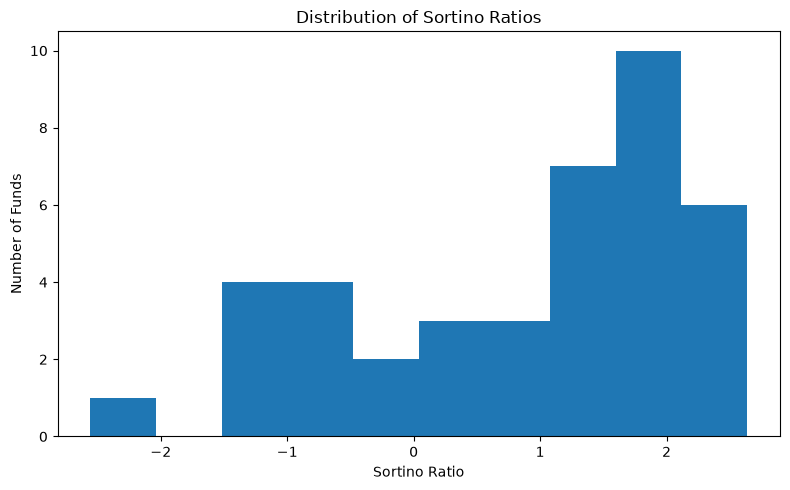

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    sortino_df["sortino_ratio"],
    bins=10
)

plt.title("Distribution of Sortino Ratios")
plt.xlabel("Sortino Ratio")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    "../reports/Sortino_Ratio_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Alpha and Beta Analysis

### Objective

Estimate Alpha and Beta relative to the NIFTY100 benchmark.

Using linear regression:

Fund Return = Alpha + Beta × Benchmark Return

Where:

- Alpha = annualized excess return not explained by the benchmark
- Beta = sensitivity to benchmark movements

Task specification:

Alpha = intercept × 252
Beta = regression slope

In [19]:
nifty100 = bench[
    bench["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [20]:
benchmark_returns = nifty100[
    ["date", "benchmark_return"]
]

fund_benchmark = nav_3yr.merge(
    benchmark_returns,
    on="date",
    how="inner"
)

print("Merged Rows:", len(fund_benchmark))

print(
    fund_benchmark[
        ["daily_return","benchmark_return"]
    ].isna().sum()
)

Merged Rows: 31400
daily_return        0
benchmark_return    0
dtype: int64


In [21]:
from scipy.stats import linregress

alpha_beta_results = []

for fund, grp in fund_benchmark.groupby("amfi_code"):

    grp = grp.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    regression = linregress(
        grp["benchmark_return"],
        grp["daily_return"]
    )

    alpha = regression.intercept * 252
    beta = regression.slope

    alpha_beta_results.append([
        fund,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

In [22]:
alpha_beta_df = alpha_beta_df.merge(
    perf[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,scheme_name,category
16,119094,0.315900,-0.100635,Axis Midcap Fund - Regular - Growth,Mid Cap
2,100033,0.291127,-0.026855,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap
34,148567,0.289333,0.018818,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap
25,120505,0.289169,-0.047272,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap
24,120504,0.272616,0.058741,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap
19,119551,0.269489,-0.051567,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
30,120843,0.266561,-0.038150,Kotak Flexicap Fund - Regular - Growth,Flexi Cap
36,148569,0.263898,-0.016235,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS
39,149324,0.261925,0.011060,DSP Small Cap Fund - Regular - Growth,Small Cap
21,119598,0.256042,-0.027706,SBI Small Cap Fund - Regular Plan - Growth,Small Cap


In [23]:
print("\nAlpha Summary")
print(alpha_beta_df["alpha"].describe())

print("\nBeta Summary")
print(alpha_beta_df["beta"].describe())


Alpha Summary
count    40.000000
mean      0.153789
std       0.103252
min      -0.081171
25%       0.061638
50%       0.167727
75%       0.250533
max       0.315900
Name: alpha, dtype: float64

Beta Summary
count    40.000000
mean     -0.002254
std       0.050391
min      -0.134265
25%      -0.033259
50%      -0.003413
75%       0.028952
max       0.165552
Name: beta, dtype: float64


In [24]:
print(bench["index_name"].unique())

<StringArray>
['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']
Length: 7, dtype: str


In [25]:
print(len(nifty100))
print(nifty100.head())

1150
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [26]:
print(
    nifty100["benchmark_return"]
    .describe()
)

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


In [27]:
test_fund = fund_benchmark[
    fund_benchmark["amfi_code"] == 119094
]

print(
    test_fund[
        ["daily_return","benchmark_return"]
    ].corr()
)

                  daily_return  benchmark_return
daily_return          1.000000         -0.066068
benchmark_return     -0.066068          1.000000


In [28]:
result = linregress(
    test_fund["benchmark_return"],
    test_fund["daily_return"]
)

print("Slope :", result.slope)
print("Intercept :", result.intercept)
print("R² :", result.rvalue**2)

Slope : -0.10063536573195962
Intercept : 0.001253571495237336
R² : 0.004364965717832404


In [29]:
print(fund_benchmark.shape)

print(fund_benchmark.head())

print(fund_benchmark.columns.tolist())

(31400, 5)
   amfi_code       date       nav  daily_return  benchmark_return
0     100016 2023-05-29  561.5519     -0.008540          0.000667
1     100016 2023-05-30  565.9312      0.007799         -0.001613
2     100016 2023-05-31  562.0590     -0.006842         -0.003352
3     100016 2023-06-01  565.0931      0.005398         -0.007142
4     100016 2023-06-02  563.6716     -0.002516          0.003643
['amfi_code', 'date', 'nav', 'daily_return', 'benchmark_return']


In [30]:
test_fund = fund_benchmark[
    fund_benchmark["amfi_code"] == 119094
]

print(test_fund[[
    "date",
    "daily_return",
    "benchmark_return"
]].head(20))

            date  daily_return  benchmark_return
12560 2023-05-29     -0.005845          0.000667
12561 2023-05-30     -0.004926         -0.001613
12562 2023-05-31     -0.019079         -0.003352
12563 2023-06-01     -0.001660         -0.007142
12564 2023-06-02      0.005596          0.003643
12565 2023-06-05     -0.005099         -0.006396
12566 2023-06-06      0.005675          0.001887
12567 2023-06-07     -0.001449          0.000191
12568 2023-06-08     -0.014803          0.005749
12569 2023-06-09      0.004419          0.002417
12570 2023-06-12     -0.001787         -0.005859
12571 2023-06-13      0.002146         -0.008572
12572 2023-06-14     -0.006092          0.009019
12573 2023-06-15     -0.007145         -0.002969
12574 2023-06-16      0.002562          0.011991
12575 2023-06-19     -0.002083         -0.020773
12576 2023-06-20      0.021541          0.001962
12577 2023-06-21      0.010288          0.007511
12578 2023-06-22      0.007224          0.001191
12579 2023-06-23    

In [31]:
test_fund["daily_return"].describe()

count    785.000000
mean       0.001218
std        0.012254
min       -0.038532
25%       -0.006967
50%        0.000723
75%        0.009474
max        0.041591
Name: daily_return, dtype: float64

In [32]:
test_fund["benchmark_return"].describe()

count    785.000000
mean       0.000353
std        0.008045
min       -0.023702
25%       -0.005141
50%        0.000281
75%        0.005456
max        0.024839
Name: benchmark_return, dtype: float64

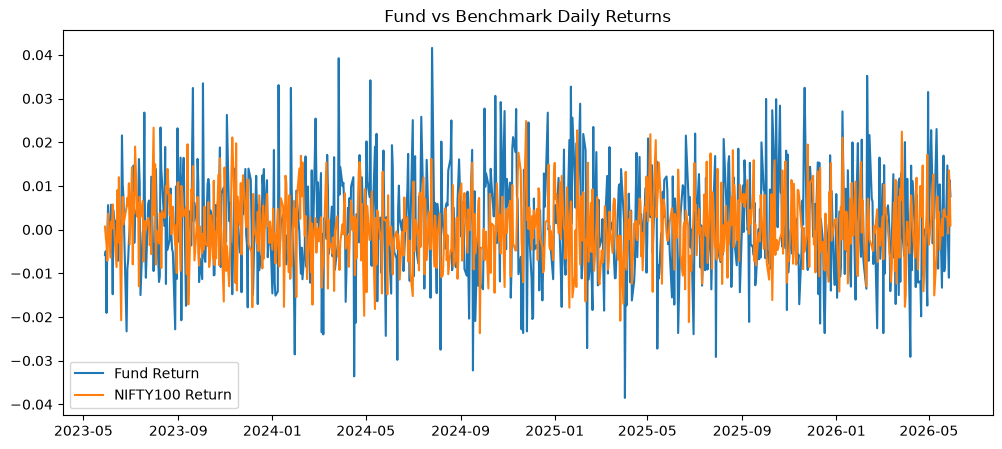

In [33]:
plt.figure(figsize=(12,5))

plt.plot(
    test_fund["date"],
    test_fund["daily_return"],
    label="Fund Return"
)

plt.plot(
    test_fund["date"],
    test_fund["benchmark_return"],
    label="NIFTY100 Return"
)

plt.legend()
plt.title("Fund vs Benchmark Daily Returns")
plt.show()

### Validation

Alpha and Beta were estimated using OLS regression
(scipy.stats.linregress) between fund daily returns
and NIFTY100 daily returns.

Alpha values are annualized by multiplying the daily
intercept by 252 trading days.

Beta values measure sensitivity of fund returns
to benchmark movements.

# 7. Maximum Drawdown Analysis

### Objective

Measure the largest peak-to-trough decline experienced by each fund.

Maximum Drawdown Formula:

Maximum Drawdown = min(NAV / Running_Max - 1)

This metric captures downside risk by identifying the worst historical loss from a previous peak.

In [34]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    fund_data = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
        .copy()
    )

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    max_dd = fund_data["drawdown"].min()

    drawdown_results.append({
        "amfi_code": fund,
        "max_drawdown": max_dd
    })

drawdown_df = pd.DataFrame(drawdown_results)

In [35]:
drawdown_df = drawdown_df.merge(
    perf[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
)

drawdown_df.head(10)

,amfi_code,max_drawdown,scheme_name,category
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth,Small Cap
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth,Small Cap
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,Small Cap
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth,Small Cap
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth,Small Cap
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth,Mid Cap
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth,Small Cap
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth,Large Cap


In [36]:
print(
    drawdown_df["max_drawdown"]
    .describe()
)

count    40.000000
mean     -0.178729
std       0.112686
min      -0.525742
25%      -0.215927
50%      -0.163070
75%      -0.117653
max      -0.000977
Name: max_drawdown, dtype: float64


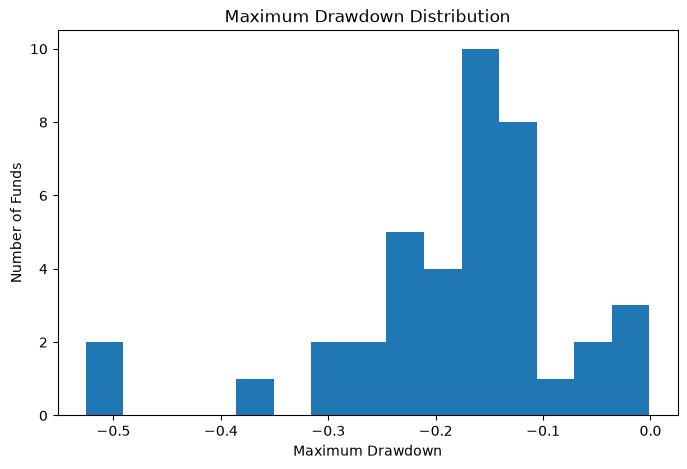

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    drawdown_df["max_drawdown"],
    bins=15
)

plt.title("Maximum Drawdown Distribution")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Number of Funds")

plt.show()

In [38]:
plt.savefig(
    "../reports/Maximum_Drawdown_Distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [39]:
drawdown_dates = []

for fund in nav["amfi_code"].unique():

    fund_data = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
        .copy()
    )

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    trough_idx = fund_data["drawdown"].idxmin()

    trough_date = fund_data.loc[
        trough_idx,
        "date"
    ]

    peak_date = fund_data.loc[
        :trough_idx,
        "nav"
    ].idxmax()

    peak_date = fund_data.loc[
        peak_date,
        "date"
    ]

    drawdown_dates.append({
        "amfi_code": fund,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "max_drawdown":
        fund_data["drawdown"].min()
    })

drawdown_dates_df = pd.DataFrame(
    drawdown_dates
)

In [40]:
drawdown_dates_df = drawdown_dates_df.merge(
    perf[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

drawdown_dates_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,peak_date,trough_date,max_drawdown,scheme_name
22,119599,2023-01-17,2025-10-28,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,2025-05-22,2026-05-11,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,2024-11-21,2026-05-11,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,2024-05-03,2025-01-03,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,2024-08-28,2025-05-14,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,2025-01-07,2026-04-27,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,2022-03-30,2022-09-15,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,2023-11-09,2024-10-17,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,2025-04-09,2026-02-20,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,2022-02-24,2023-05-22,-0.217514,Axis Bluechip Fund - Direct - Growth


In [41]:
drawdown_df["max_drawdown"].describe()

count    40.000000
mean     -0.178729
std       0.112686
min      -0.525742
25%      -0.215927
50%      -0.163070
75%      -0.117653
max      -0.000977
Name: max_drawdown, dtype: float64

In [42]:
drawdown_df.head()

,amfi_code,max_drawdown,scheme_name,category
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth,Small Cap
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth,Small Cap
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,Small Cap
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth,Small Cap
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth,Small Cap


### Observation

The average maximum drawdown across all funds is approximately 17.9%.

Small Cap funds experienced the deepest drawdowns, with the worst decline exceeding 52%, highlighting their higher volatility and downside risk.

Funds with lower maximum drawdowns demonstrate better capital preservation during market downturns.

### Business Insight

Maximum Drawdown is an important risk metric because it measures the largest historical loss an investor would have experienced.

While high-return funds may generate superior long-term growth, they often come with larger drawdowns. Investors with lower risk tolerance may prefer funds that maintain smaller drawdowns even if returns are slightly lower.

# 8. Fund Scorecard 

### Objective

Create a composite fund score (0–100) by combining return, risk-adjusted return, alpha generation, expense efficiency, and downside risk.

Weights:

- 30% CAGR Rank
- 25% Sharpe Rank
- 20% Alpha Rank
- 15% Expense Ratio Rank (Inverse)
- 10% Maximum Drawdown Rank (Inverse)

In [43]:
scorecard_df = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "category",
        "cagr_3yr"
    ]
].copy()

In [44]:
scorecard_df = scorecard_df.merge(
    sharpe_df[
        [
            "amfi_code",
            "sharpe_ratio"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [45]:
scorecard_df = scorecard_df.merge(
    alpha_beta_df[
        [
            "amfi_code",
            "alpha"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [46]:
scorecard_df = scorecard_df.merge(
    perf[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [47]:
scorecard_df = scorecard_df.merge(
    drawdown_df[
        [
            "amfi_code",
            "max_drawdown"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [48]:
scorecard_df.head()

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,119094,Axis Midcap Fund - Regular - Growth,Mid Cap,0.351118,1.243753,0.315900,1.38,-0.209609
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,0.340009,1.614434,0.289333,1.46,-0.112657
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,0.324874,1.479645,0.272616,0.80,-0.125883
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,0.324425,1.224870,0.291127,1.38,-0.162172
4,120505,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.317775,1.155939,0.289169,1.36,-0.181885


In [49]:
scorecard_df["cagr_rank"] = (
    scorecard_df["cagr_3yr"]
    .rank(ascending=False)
)

scorecard_df["sharpe_rank"] = (
    scorecard_df["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard_df["alpha_rank"] = (
    scorecard_df["alpha"]
    .rank(ascending=False)
)

scorecard_df["expense_rank"] = (
    scorecard_df["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard_df["drawdown_rank"] = (
    scorecard_df["max_drawdown"]
    .rank(ascending=False)
)

In [50]:
scorecard_df["raw_score"] = (

    scorecard_df["cagr_rank"] * 0.30 +

    scorecard_df["sharpe_rank"] * 0.25 +

    scorecard_df["alpha_rank"] * 0.20 +

    scorecard_df["expense_rank"] * 0.15 +

    scorecard_df["drawdown_rank"] * 0.10

)

In [51]:
scorecard_df["fund_score"] = (

    (scorecard_df["raw_score"].max()
     - scorecard_df["raw_score"])

    /

    (scorecard_df["raw_score"].max()
     - scorecard_df["raw_score"].min())

) * 100

In [52]:
scorecard_df = scorecard_df.sort_values(
    "fund_score",
    ascending=False
)

scorecard_df.head(10)

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,raw_score,fund_score
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,0.324874,1.479645,0.272616,0.80,-0.125883,3.0,2.0,5.0,12.0,12.0,5.400,100.000000
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,0.340009,1.614434,0.289333,1.46,-0.112657,2.0,1.0,3.0,23.0,8.0,5.700,99.009901
0,119094,Axis Midcap Fund - Regular - Growth,Mid Cap,0.351118,1.243753,0.315900,1.38,-0.209609,1.0,6.0,1.0,17.0,28.0,7.350,93.564356
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,0.324425,1.224870,0.291127,1.38,-0.162172,4.0,7.0,2.0,17.0,20.0,7.900,91.749175
4,120505,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.317775,1.155939,0.289169,1.36,-0.181885,5.0,8.0,4.0,15.0,25.0,9.050,87.953795
6,120843,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,0.295828,1.252066,0.266561,1.45,-0.129740,7.0,5.0,7.0,22.0,13.0,9.350,86.963696
5,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,0.304565,1.433735,0.269489,1.54,-0.150124,6.0,3.0,6.0,30.5,17.0,10.025,84.735974
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Large Cap,0.289677,1.298103,0.248697,1.60,-0.112916,9.0,4.0,11.0,36.5,9.0,12.275,77.310231
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,0.291789,1.135917,0.263898,1.60,-0.163967,8.0,9.0,8.0,36.5,21.0,13.825,72.194719
14,118633,Nippon India Large Cap Fund - Direct - Growth,Large Cap,0.210900,0.909355,0.195721,0.72,-0.186297,15.0,15.0,15.0,5.5,26.0,14.675,69.389439


In [55]:
scorecard_df[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
2,ICICI Pru Bluechip Fund - Direct - Growth,100.000000
1,Mirae Asset Large Cap Fund - Regular - Growth,99.009901
0,Axis Midcap Fund - Regular - Growth,93.564356
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,91.749175
4,ICICI Pru Midcap Fund - Regular - Growth,87.953795
6,Kotak Flexicap Fund - Regular - Growth,86.963696
5,SBI Bluechip Fund - Regular Plan - Growth,84.735974
8,ABSL Frontline Equity Fund - Regular - Growth,77.310231
7,Mirae Asset Tax Saver Fund - Regular - Growth,72.194719
14,Nippon India Large Cap Fund - Direct - Growth,69.389439


In [53]:
print(
    scorecard_df["fund_score"]
    .describe()
)

count     40.000000
mean      50.165017
std       28.509510
min        0.000000
25%       28.960396
50%       52.887789
75%       69.327558
max      100.000000
Name: fund_score, dtype: float64


In [54]:
scorecard_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


### Validation

Fund scores were normalized to a 0–100 scale.

Higher scores indicate stronger overall performance across return, risk-adjusted return, alpha generation, expense efficiency, and downside protection.

The scoring methodology balances both return and risk characteristics rather than relying on a single metric.

### Business Insight

A composite score provides a holistic ranking framework that balances both return and risk characteristics.

Rather than selecting funds solely on returns, the scorecard identifies funds that have delivered consistent performance while maintaining efficient costs and controlled downside risk.

Funds with consistently strong returns, superior risk-adjusted performance, lower expenses, and controlled drawdowns achieve higher scores, making them attractive candidates for long-term investors.

# 9.Benchmark Comparison analysis 

### Objective

Compare the top 5 ranked funds against NIFTY50 and NIFTY100 over the last 3 years.

Additionally, calculate Tracking Error:

Tracking Error = std(Fund Return − Benchmark Return) × √252

Lower tracking error indicates closer movement to the benchmark, while higher tracking error indicates greater deviation from benchmark performance.

In [56]:
top5_funds = (
    scorecard_df
    .head(5)["amfi_code"]
    .tolist()
)

print(top5_funds)

[120504, 148567, 119094, 100033, 120505]


In [57]:
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3yr = nav[
    nav["date"] >= start_date
].copy()

print(nav_3yr["date"].min())
print(nav_3yr["date"].max())

2023-05-29 00:00:00
2026-05-29 00:00:00


In [58]:
fund_plot_data = []

for fund in top5_funds:

    fund_data = (
        nav_3yr[
            nav_3yr["amfi_code"] == fund
        ]
        .sort_values("date")
        .copy()
    )

    base_nav = fund_data["nav"].iloc[0]

    fund_data["normalized_index"] = (
        fund_data["nav"] / base_nav
    ) * 100

    fund_plot_data.append(fund_data)

fund_plot = pd.concat(
    fund_plot_data,
    ignore_index=True
)

In [59]:
print(
    bench["index_name"]
    .unique()
)

<StringArray>
['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']
Length: 7, dtype: str


In [60]:
nifty50 = (
    bench[
        bench["index_name"] == "NIFTY50"
    ]
    .copy()
)

nifty100 = (
    bench[
        bench["index_name"] == "NIFTY100"
    ]
    .copy()
)

nifty50 = nifty50[
    nifty50["date"] >= start_date
].sort_values("date")

nifty100 = nifty100[
    nifty100["date"] >= start_date
].sort_values("date")

In [61]:
nifty50["normalized_index"] = (
    nifty50["close_value"]
    /
    nifty50["close_value"].iloc[0]
) * 100

nifty100["normalized_index"] = (
    nifty100["close_value"]
    /
    nifty100["close_value"].iloc[0]
) * 100

In [62]:
fund_plot = fund_plot.merge(
    perf[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

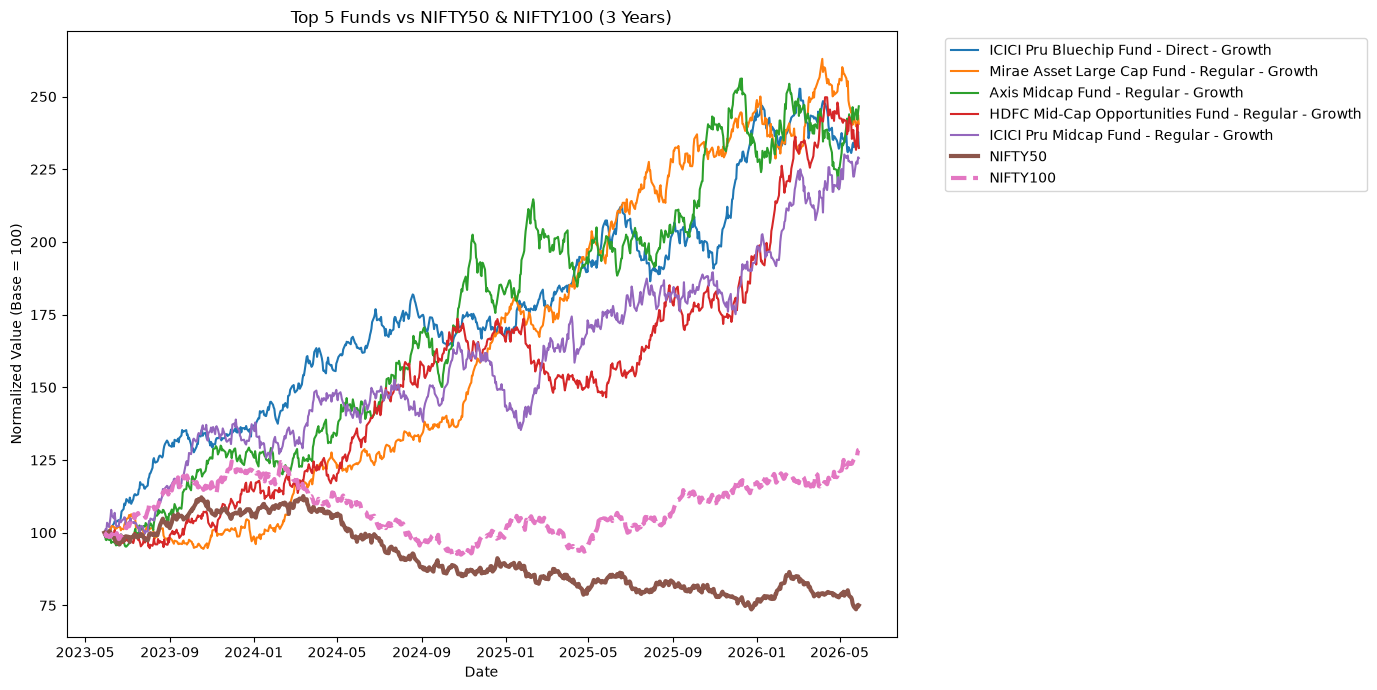

In [63]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = fund_plot[
        fund_plot["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["normalized_index"],
        label=temp["scheme_name"].iloc[0]
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized_index"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized_index"],
    linewidth=3,
    linestyle="--",
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [64]:
plt.savefig(
    "../reports/benchmark_comparison_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [65]:
print(nifty50.shape)
print(nifty100.shape)

print(nifty50.head())
print(nifty100.head())

(785, 4)
(785, 4)
          date index_name  close_value  normalized_index
365 2023-05-29    NIFTY50     24688.69        100.000000
366 2023-05-30    NIFTY50     24558.17         99.471337
367 2023-05-31    NIFTY50     24476.07         99.138796
368 2023-06-01    NIFTY50     24375.89         98.733023
369 2023-06-02    NIFTY50     24398.93         98.826345
           date index_name  close_value  normalized_index
1515 2023-05-29   NIFTY100     15324.41        100.000000
1516 2023-05-30   NIFTY100     15299.69         99.838689
1517 2023-05-31   NIFTY100     15248.41         99.504059
1518 2023-06-01   NIFTY100     15139.50         98.793363
1519 2023-06-02   NIFTY100     15194.66         99.153312


In [67]:
print(bench.columns.tolist())

['date', 'index_name', 'close_value']


In [68]:
bench.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [69]:
print(bench.columns.tolist())
bench.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [70]:
bench = bench.sort_values(
    ["index_name", "date"]
)

bench["benchmark_return"] = (
    bench.groupby("index_name")["close_value"]
    .pct_change()
)

print(bench.head())

           date    index_name  close_value  benchmark_return
3450 2022-01-03  BSE_SMALLCAP     26554.60               NaN
3451 2022-01-04  BSE_SMALLCAP     27079.92          0.019783
3452 2022-01-05  BSE_SMALLCAP     27313.35          0.008620
3453 2022-01-06  BSE_SMALLCAP     27377.05          0.002332
3454 2022-01-07  BSE_SMALLCAP     26316.86         -0.038726


In [71]:
print(bench.columns.tolist())

['date', 'index_name', 'close_value', 'benchmark_return']


In [72]:
# Tracking Error Analysis

tracking_error_list = []

for fund in top5_funds:

    fund_returns = (
        nav_3yr[
            nav_3yr["amfi_code"] == fund
        ][
            ["date", "daily_return"]
        ]
        .copy()
    )

    benchmark_returns = (
        bench[
            bench["index_name"] == "NIFTY100"
        ][
            ["date", "benchmark_return"]
        ]
        .copy()
    )

    merged = (
        fund_returns.merge(
            benchmark_returns,
            on="date",
            how="inner"
        )
        .dropna()
    )

    tracking_error = (
        (
            merged["daily_return"]
            - merged["benchmark_return"]
        )
        .std()
        * np.sqrt(252)
    )

    tracking_error_list.append(
        {
            "amfi_code": fund,
            "tracking_error": tracking_error
        }
    )

tracking_error_df = pd.DataFrame(
    tracking_error_list
)

tracking_error_df = tracking_error_df.merge(
    perf[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

tracking_error_df = tracking_error_df.sort_values(
    "tracking_error"
)

tracking_error_df

,amfi_code,tracking_error,scheme_name
0,120504,0.187312,ICICI Pru Bluechip Fund - Direct - Growth
1,148567,0.187867,Mirae Asset Large Cap Fund - Regular - Growth
3,100033,0.224838,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120505,0.232515,ICICI Pru Midcap Fund - Regular - Growth
2,119094,0.239658,Axis Midcap Fund - Regular - Growth


In [73]:
print(
    tracking_error_df["tracking_error"]
    .describe()
)

count    5.000000
mean     0.214438
std      0.025064
min      0.187312
25%      0.187867
50%      0.224838
75%      0.232515
max      0.239658
Name: tracking_error, dtype: float64


### Validation

- Tracking Error measures how closely a fund follows its benchmark.
- Lower values indicate benchmark-like performance.
- Higher values indicate greater deviation from benchmark returns.
- All values should be positive.

# 10. Export Deliverables

In [74]:
scorecard_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Files exported successfully.")

Files exported successfully.


# 11. Conclusions

### Daily Return Analysis
- Daily returns were centered close to zero with a near bell-shaped distribution.
- Average daily return across funds was positive, indicating long-term growth potential.
- Expected missing values were observed only for the first NAV record of each fund.

### CAGR Analysis
- Several Mid Cap and Large Cap funds achieved strong 3-Year CAGR performance.
- CAGR proved useful for comparing long-term growth consistency across schemes.

### Risk-Adjusted Performance
- Sharpe and Sortino ratios identified funds delivering superior returns relative to risk.
- Large Cap funds generally demonstrated stronger risk-adjusted performance.

### Alpha & Beta Analysis
- Positive alpha values indicated that several funds outperformed the benchmark.
- Most funds exhibited relatively low beta values, suggesting moderate market sensitivity.

### Maximum Drawdown Analysis
- Small Cap funds experienced the deepest drawdowns.
- Funds with lower drawdowns demonstrated stronger downside protection.

### Fund Scorecard
- A composite score combining CAGR, Sharpe Ratio, Alpha, Expense Ratio, and Drawdown was developed.
- ICICI Pru Bluechip Fund, Mirae Asset Large Cap Fund, and Axis Midcap Fund ranked among the highest-scoring schemes.

### Benchmark Comparison
- Top-ranked funds generally outperformed benchmark indices over the analysis period.
- Tracking Error values indicated moderate deviation from benchmark returns, reflecting active fund management.

## Business Insights

- Risk-adjusted metrics are essential when evaluating mutual fund performance.
- Strong returns alone are insufficient without considering volatility and drawdown risk.
- Investors seeking stability may prefer funds with higher Sharpe Ratios and lower drawdowns.
- Active fund managers can generate positive alpha while maintaining acceptable tracking error levels.
- A composite scorecard provides a more balanced framework for mutual fund selection than any single metric.

## Final Conclusion

The analysis demonstrates that combining return, risk, consistency, and cost metrics provides a comprehensive framework for evaluating mutual fund performance. The developed scorecard successfully identifies funds that balance growth potential with risk management, making it a useful tool for investment decision-making and future dashboard integration.